# 04 · Does the method preserve more motion at the same repair quality?

**This is the decision notebook.** It compares locked operating points
and asks whether the gain survives stronger baselines, uncertainty and
held-out conditions. Default evaluation uses development cases only.

Run each notebook in a fresh kernel, in order **00 → 04**. Notebook 05 is
an external visual stress test. These are offline restoration experiments:
the model may inspect the declared complete clip. They do not claim causal
forecasting or clinical diagnosis.

**The default is real data.** Export `MP_RUN_ROOT`, the AMASS and GAVD data
paths, and the model configuration before opening Jupyter. See the
[launch guide](../../../../../slurm/motion-preservation/README.md).
For a CPU walkthrough of the mechanics, explicitly choose `MP_MODE=demo`
and a separate run directory. Demo outputs cannot establish a research result.

[Proposal](../../../../../docs/studies/motion-preservation/protocol/proposal.md)
· [Notebook guide](../../../../../notebooks/motion_preservation/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

project_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(project_override).expanduser()] if project_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)  # Resolve manifest/config paths from the checkout in every kernel.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, Video, display
from gavd6_sjepa.research_directions.motion_preservation import workflow, plots

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
cfg = workflow.config_from_environment()
RUN_ROOT = Path(cfg.run_root)
print(f"Mode: {cfg.mode}; run directory: {RUN_ROOT}")
if cfg.mode == "demo":
    display(Markdown("**DEMO ONLY: generated fixtures and stand-in models. "
                     "These outputs are not evidence about AMASS, GAVD, or a pretrained prior.**"))

Mode: real; run directory: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/motion-preservation/pilot-01


## 1. Choose the evaluation boundary explicitly

`MP_EVALUATION_SPLIT=development` gives the 48-hour pilot decision.
`MP_EVALUATION_SPLIT=final` opens the reserved event family and people.
Final mode builds and caches those cases only after the gate and
operating points exist. It never calls training or calibration.

The implemented final setting combines a new event family, camera angle
and corruption mechanism. It measures combined stress robustness, not
isolated event generalization. Separate matched nuisance ablations are
needed to attribute an effect to one of these changes.

If you change the method after seeing the final result, that result is
development evidence and a new independent final set is needed.

In [2]:
SPLIT = os.environ.get("MP_EVALUATION_SPLIT", "development")
if SPLIT not in {"development", "final"}:
    raise ValueError("MP_EVALUATION_SPLIT must be development or final.")
print(f"Evaluation role: {SPLIT}")
if SPLIT == "final":
    workflow.require_fitted(cfg)
    print("Opening the reserved final cases with the saved gate and calibration.")
    final_cases = workflow.build_pairs(cfg, roles=("final",))
    final_cache = workflow.cache_predictions(cfg, roles=("final",))
    print(f"Final cases: {len(final_cases):,}; cached rows: {len(final_cache):,}")

Evaluation role: development


## 2. Read the two axes correctly

For event descriptor `d`, clean motion `x` and edited truth `x_event`,
event magnitude is `a = d(x_event) - d(x)`. Retention for output `y` is

`1 - abs(d(y) - d(x_event)) / abs(a)`.

One means the event descriptor matches its reference. Zero means an error as
large as the event itself. Negative retention is allowed and must not
be clipped away. Overshoot and signed errors are reported separately.

Repair uses squared 3D error at observed joints, measured against the
correct truth for the case, including `x_event` when an event is present.
Noise removal of 0.25 means a quarter of that observed-joint squared
error was removed. The raw and repaired scores use the same mask.

Missing joints are interpolated before the prior runs. Their separate
`completion_mse_m2` score measures gap filling. Also inspect
`observed_mse_m2`, all-joint `mse_m2`, and `missing_fraction`. Missing
joints cannot inflate the primary repair ratio.

In [3]:
# Worked metric example only. These numbers are not model results.
event_magnitude = 0.10
reference_descriptor = 0.10
candidate_descriptors = np.array([0.10, 0.07, 0.00, 0.23])
display(pd.DataFrame({"candidate_descriptor": candidate_descriptors,
                      "retention": 1 - np.abs(candidate_descriptors - reference_descriptor) / event_magnitude,
                      "signed_event_error": candidate_descriptors - reference_descriptor}))

,candidate_descriptor,retention,signed_event_error
0,0.10,1.0,0.00
1,0.07,0.7,-0.03
2,0.00,0.0,-0.10
3,0.23,-0.3,0.13


## 3. Evaluate the saved operating points

Inspect achieved noise removal alongside retention. Calibration may not
transfer perfectly, so two methods can achieve different removal on new
people despite sharing a calibration target. Do not call a retention
gain a matched-quality improvement if repair quality is materially worse.
Both methods must reach the target on event-plus-noise cases, as well
as in the overall noisy-case average.

In [4]:
started = perf_counter()
report = workflow.evaluate(cfg, split=SPLIT)
print(f"Evaluation completed in {perf_counter() - started:.1f} seconds.")
display(report["summary"])

Evaluation completed in 10.3 seconds.


,method,retention,noise_removal,descriptor_abs_error,mse_m2,observed_mse_m2,completion_mse_m2,missing_fraction,n_people,event_and_noise_removal,unedited_motion_descriptor_error,coverage,brier,selective_accuracy,ambiguous_brier,ambiguous_coverage
0,raw,0.855359,0.000000,0.011682,0.000027,0.000027,0.000159,0.000541,8,0.000000,0.005267,NaN,NaN,NaN,NaN,NaN
1,projected_raw,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000195,0.000541,8,-0.538876,0.012269,NaN,NaN,NaN,NaN,NaN
2,prior,0.786111,-0.546982,0.019597,0.000041,0.000040,0.002438,0.000541,8,-0.538877,0.012477,NaN,NaN,NaN,NaN,NaN
3,conversion_only,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000281,0.000541,8,-0.538877,0.012269,NaN,NaN,NaN,NaN,NaN
4,prior_unprojected,0.332565,-86.365216,0.041677,0.002423,0.002420,0.006055,0.000541,8,-87.472473,0.011953,NaN,NaN,NaN,NaN,NaN
5,conversion_only_unprojected,0.768113,-1.056627,0.022345,0.000055,0.000055,0.000280,0.000541,8,-1.055767,0.013827,NaN,NaN,NaN,NaN,NaN
6,gaussian,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000253,0.000541,8,-0.538877,0.012269,NaN,NaN,NaN,NaN,NaN
7,median,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000249,0.000541,8,-0.538877,0.012269,NaN,NaN,NaN,NaN,NaN
8,kalman,0.786111,-0.546982,0.019597,0.000040,0.000040,0.000272,0.000541,8,-0.538877,0.012269,NaN,NaN,NaN,NaN,NaN
9,confidence_gate,0.786111,-0.546982,0.019597,0.000041,0.000040,0.002615,0.000541,8,-0.538877,0.012624,NaN,NaN,NaN,NaN,NaN


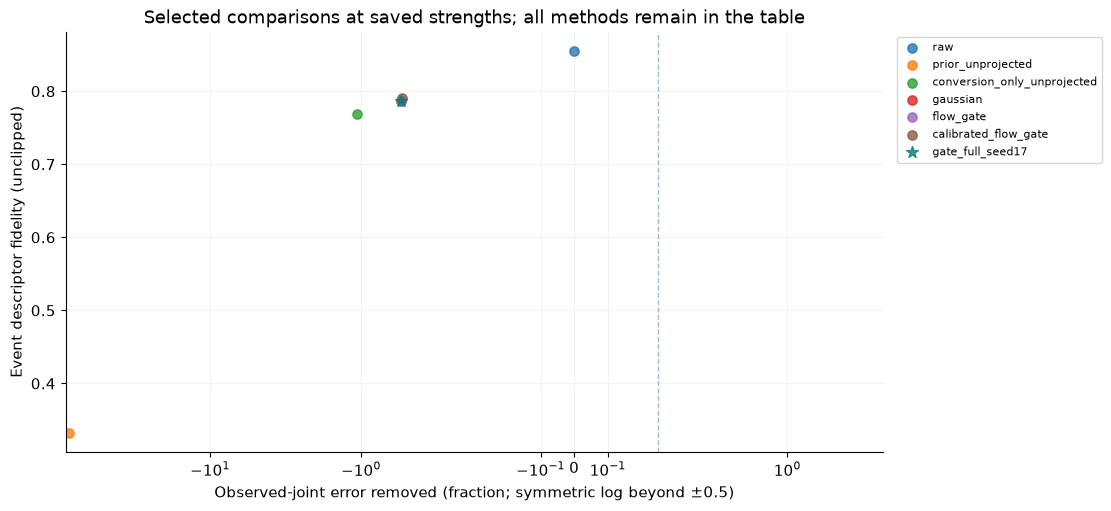

In [5]:
figure = plots.plot_tradeoff(report)
display(figure)
plt.close(figure)

## 4. Examine the cases behind the average

Check event-only and event-plus-noise groups separately. The latter is
the stronger test. Examine reliable and unreliable flow, held cameras,
missing observations and the observation-equivalent occlusion fixture.
An aggregate can hide a method that succeeds only when no repair is needed.

Confidence intervals should resample people with every trial and variant
kept together. If the manifest supplies only an uncertain group identity,
label the result accordingly. Repeated optimization seeds do not create
new independent people.

In [6]:
scores = report["scores"]
display(scores.head(20))
grouping = [c for c in ("method", "fixture", "event_family", "event_present", "noise_present", "condition")
            if c in scores]
quantities = [c for c in ("retention", "noise_removal", "descriptor_abs_error", "descriptor_signed_error", "brier", "decided")
              if c in scores]
if grouping and quantities:
    display(scores.groupby(grouping, dropna=False)[quantities].mean())

,case_id,person_id,role,event_family,fixture,event_present,noise_present,method,strength,mse_m2,...,retention,descriptor_abs_error,descriptor_signed_error,event_magnitude,event_eligible,signed_event_error,probability,brier,decided,correct
0,development_0000_KIT__348_factorial_event0_noise0,KIT::348,development,foot_clearance,factorial,False,False,raw,1.0,0.000000,...,NaN,0.000000,0.000000,0.139142,False,NaN,NaN,NaN,NaN,NaN
1,development_0000_KIT__348_factorial_event0_noise1,KIT::348,development,foot_clearance,factorial,False,True,raw,1.0,0.000022,...,NaN,0.008787,-0.008787,0.139142,False,NaN,NaN,NaN,NaN,NaN
2,development_0000_KIT__348_factorial_event1_noise0,KIT::348,development,foot_clearance,factorial,True,False,raw,1.0,0.000000,...,1.000000,0.000000,0.000000,0.139142,True,0.000000,NaN,NaN,NaN,NaN
3,development_0000_KIT__348_factorial_event1_noise1,KIT::348,development,foot_clearance,factorial,True,True,raw,1.0,0.000022,...,0.878185,0.016950,-0.016950,0.139142,True,-0.121815,NaN,NaN,NaN,NaN
4,development_0000_KIT__348_matched_real,KIT::348,development,foot_clearance,matched,True,True,raw,1.0,0.000022,...,0.878185,0.016950,-0.016950,0.139142,True,-0.121815,NaN,NaN,NaN,NaN
5,development_0000_KIT__348_matched_tracking_fai...,KIT::348,development,foot_clearance,matched,False,True,raw,1.0,0.000569,...,NaN,0.122193,0.122193,0.139142,False,NaN,NaN,NaN,NaN,NaN
6,development_0000_KIT__348_matched_real_ambiguous,KIT::348,development,foot_clearance,ambiguous,True,True,raw,1.0,0.000022,...,0.878185,0.016950,-0.016950,0.139142,True,-0.121815,NaN,NaN,NaN,NaN
7,development_0000_KIT__348_matched_tracking_fai...,KIT::348,development,foot_clearance,ambiguous,False,True,raw,1.0,0.000569,...,NaN,0.122193,0.122193,0.139142,False,NaN,NaN,NaN,NaN,NaN
8,development_0001_ACCAD__Male2_factorial_event0...,ACCAD::Male2,development,foot_clearance,factorial,False,False,raw,1.0,0.000000,...,NaN,0.000000,0.000000,0.090300,False,NaN,NaN,NaN,NaN,NaN
9,development_0001_ACCAD__Male2_factorial_event0...,ACCAD::Male2,development,foot_clearance,factorial,False,True,raw,1.0,0.000037,...,NaN,0.015176,0.015176,0.090300,False,NaN,NaN,NaN,NaN,NaN


retention  \
method               fixture   event_family   event_present noise_present              
calibrated_flow_gate ambiguous foot_clearance False         True                 NaN   
                                              True          True            0.791744   
                     factorial foot_clearance False         False                NaN   
                                                            True                 NaN   
                                              True          False           0.958840   
...                                                                              ...   
raw                  factorial foot_clearance False         True                 NaN   
                                              True          False           1.000000   
                                                            True            0.855359   
                     matched   foot_clearance False         True                 NaN   
                                              True          True            0.855359   

                                                                           noise_removal  \
method               fixture   event_family   event_present noise_present                  
calibrated_flow_gate ambiguous foot_clearance False         True               -0.033987   
                                              True          True               -0.527406   
                     factorial foot_clearance False         False                    NaN   
                                                            True               -0.547120   
                                              True          False                    NaN   
...                                                                                  ...   
raw                  factorial foot_clearance False         True                0.000000   
                                              True          False                    NaN   
                                                            True                0.000000   
                     matched   foot_clearance False         True                0.000000   
                                              True          True                0.000000   

                                                                           descriptor_abs_error  \
method               fixture   event_family   event_present noise_present                         
calibrated_flow_gate ambiguous foot_clearance False         True                       0.128538   
                                              True          True                       0.019431   
                     factorial foot_clearance False         False                      0.005927   
                                                            True                       0.019226   
                                              True          False                      0.003897   
...                                                                                         ...   
raw                  factorial foot_clearance False         True                       0.010534   
                                              True          False                      0.000000   
                                                            True                       0.012829   
                     matched   foot_clearance False         True                       0.117563   
                                              True          True                       0.012829   

                                                                           descriptor_signed_error  \
method               fixture   event_family   event_present noise_present                            
calibrated_flow_gate ambiguous foot_clearance False         True                          0.128538   
                                              True          True                          0.018923   
                     factorial foot_c

## 5. Make the 48-hour decision

The proposal's provisional development target is at least **15 percentage
points more retention** than the strongest baseline, while removing at
least **25% of injected error**, with comparable achieved repair and a
person-grouped interval supporting improvement. These are practical
thresholds, not predicted effects or a promise of publication.

Stop the method claim if simple calibrated flow matches the learned
frontier, the gain vanishes after nuisance controls, or the prior never
meaningfully erases true events. Use a poor reference-informed mixture
diagnostic to reconsider the gate design, without calling it a certified
upper bound after projection.
Dropping an unhelpful optional V-JEPA feature branch does not invalidate
a useful flow-supported adapter.

In [7]:
decision = report["decision"]
display(Markdown("```json\n" + json.dumps(decision, indent=2, default=str) + "\n```"))
if cfg.mode == "demo":
    print("Ignore empirical continue/stop interpretations: this run tests pipeline mechanics only.")

```json
{
  "status": "development_stop",
  "split": "development",
  "mode": "real",
  "prior_id": "momask",
  "trained_prior": "momask",
  "noise_removal_scope": "observed_joints",
  "target_noise_removal": 0.25,
  "primary": "gate_full_seed17",
  "calibration_selected_comparator": "calibrated_flow_gate",
  "retention_difference": {
    "mean": -0.004576915939058859,
    "low": -0.007846983647700593,
    "high": -0.0009779958333944688,
    "n_people": 8
  },
  "matched_achieved_repair": true,
  "minimum_repair_met": false,
  "primary_noise_removal": -0.5469822258889965,
  "comparator_noise_removal": -0.5369017237997581,
  "same_clip_event_and_noise_repair": false,
  "seed_retention_gains": {
    "gate_full_seed17": -0.004576915939058734
  },
  "final_shift": null,
  "oracle_note": "Reference-informed pointwise mixture before projection; not a certified optimum after projection.",
  "shortcut_probe": {
    "status": "no_observed_shortcut_in_this_probe",
    "balanced_accuracy": 0.5,
    "n_people": 8,
    "features": [
      "duration",
      "centroid_drift",
      "joint_speed",
      "foreground_fraction",
      "flow_energy",
      "confidence",
      "missingness"
    ]
  },
  "seed_methods": [
    "gate_full_seed17"
  ],
  "interpretation": "A pilot decision, not evidence of clinical validity or publication readiness.",
  "missing_exact_comparisons": [
    "HTD-Refine",
    "MFTIQ",
    "H-MoRe",
    "two_tracker"
  ]
}
```

## What comes after a passing pilot?

Expand to three optimization seeds and more people, then evaluate the
reserved family once. A second prior requires a new set of predictions
for the same cases, matching the original feature convention. Keep the
learned gate and calibration fixed if claiming transfer across priors.
Do not call a smoother a second foundation prior.

Natural AMASS events and GAVD inspection test whether the synthetic
result transfers. A successful demo or synthetic-only result is not the
full proposed ICLR contribution.

Next: [05 · Inspect GAVD stress cases](05_gavd_visual_stress.ipynb).